In [1]:
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2

from src.runners import run_vqe_trace, run_vqe_trace_shots
from src.transformations import (
    vqe_identity,
    vqe_barrier,
    vqe_identity_xx,
    vqe_fault_x,
    vqe_fault_replace_rotation,
    vqe_fault_replace_rotation_strong,
    vqe_fault_shift_parameter,
    vqe_fault_shift_parameter_strong,
    vqe_fault_change_entanglement,
)
from src.checker import evaluate_vqe_pair, compare_vqe_traces, evaluate_vqe_pair_shot_based

In [2]:
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12})

project_root = Path.cwd().parent
results_dir = project_root / "results"
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("VQE Metamorphic Shot-based Testing Notebook")
print("=" * 50)
print(f"Project root: {project_root}")
print(f"Results dir: {results_dir}")
print(f"Figures dir: {figures_dir}")

VQE Metamorphic Shot-based Testing Notebook
Project root: C:\Users\shask\Desktop\metamorphic_quantum_testing-20260507T174858Z-3-001\metamorphic_quantum_testing
Results dir: C:\Users\shask\Desktop\metamorphic_quantum_testing-20260507T174858Z-3-001\metamorphic_quantum_testing\results
Figures dir: C:\Users\shask\Desktop\metamorphic_quantum_testing-20260507T174858Z-3-001\metamorphic_quantum_testing\results\figures


In [3]:
# PHASE 2: SHOT-BASED VQE METAMORPHIC TESTING

PHASE = "shot_based"

NUM_QUBITS = 4
NUM_RUNS = 10

REPS = 5
MAXITER = 60
SHOTS = 2048

# Tuned thresholds for shot-based phase
ENERGY_THRESHOLD = 5e-2
SYMMETRY_THRESHOLD = 1e-2

# Parameter-path as diagnostic only in shot-based phase
PARAM_THRESHOLD = float("inf")

RANDOM_SEED = 42

# if we want to save representative traces for plotting
SAVE_TRACE_LEVEL = False 

# HAMILTONIAN + SYMMETRY

H = SparsePauliOp(
    ["ZZII", "IIZZ", "XXII", "IIXX"],
    coeffs=[-1.0, -1.0, 0.5, 0.5]
)

symmetry_op = SparsePauliOp(
    ["ZZII", "IIZZ"],
    coeffs=[1.0, 1.0]
)

# COMMUTATOR CHECK

def check_commutation(A, B, label_A="A", label_B="B"):
    comm = (A @ B - B @ A).simplify(atol=1e-12)

    print(f"\nCommutator [{label_A}, {label_B}]:")
    print(comm)

    if len(comm.paulis) == 0 or np.allclose(comm.coeffs, 0.0):
        print("Result: operators commute.\n")
        return True
    else:
        print("Result: operators do NOT commute.\n")
        return False

commutes = check_commutation(H, symmetry_op, "H", "symmetry_op")

# ANSATZ

ansatz = efficient_su2(
    NUM_QUBITS,
    reps=REPS,
    entanglement="full",
)

print("Original ansatz:")
print(f"Number of qubits: {ansatz.num_qubits}")
print(f"Number of parameters: {ansatz.num_parameters}")
print(f"Circuit depth: {ansatz.depth()}")

# RELATIONS

relations = {
    "identity": {
        "transform": vqe_identity,
        "type": "valid",
    },
    "barrier": {
        "transform": vqe_barrier,
        "type": "valid",
    },
    "identity_xx": {
        "transform": vqe_identity_xx,
        "type": "valid",
    },
    "fault_x": {
        "transform": vqe_fault_x,
        "type": "fault",
    },
    "fault_replace_rot": {
        "transform": vqe_fault_replace_rotation,
        "type": "fault",
    },
    "fault_replace_rot_strong": {
        "transform": vqe_fault_replace_rotation_strong,
        "type": "fault",
    },
    "fault_shift_param": {
        "transform": vqe_fault_shift_parameter,
        "type": "fault",
    },
    "fault_shift_param_strong": {
        "transform": vqe_fault_shift_parameter_strong,
        "type": "fault",
    },
    "fault_change_entanglement": {
        "transform": vqe_fault_change_entanglement,
        "type": "fault",
    },
}

def apply_transform(transform, ansatz, seed):
    try:
        return transform(ansatz, seed=seed)
    except TypeError:
        return transform(ansatz)

# INITIAL POINTS

rng = np.random.default_rng(RANDOM_SEED)

initial_points = [
    rng.uniform(-0.1, 0.1, ansatz.num_parameters)
    for _ in range(NUM_RUNS)
]

# MAIN EXPERIMENT

results_shot = []
run_level_results_shot = []
trace_frames_shot = [] if SAVE_TRACE_LEVEL else None

print(
    f"\nRunning {PHASE} VQE metamorphic testing "
    f"({NUM_RUNS} paired runs per relation, {SHOTS} shots)...\n"
)

for relation_name, relation_info in relations.items():
    transform = relation_info["transform"]
    relation_type = relation_info["type"]

    print(f"→ Testing: {relation_name}")

    delta_E_list = []
    avg_energy_diff_list = []
    max_energy_diff_list = []

    avg_sym_diff_list = []
    max_sym_diff_list = []

    avg_param_diff_list = []
    max_param_diff_list = []

    detected_list = []

    for run in range(NUM_RUNS):
        initial_point = initial_points[run]

        # ONE shared seed for the metamorphic pair
        pair_seed = 100_000 + run
        transform_seed = 1_000 + run

        # Follow-up ansatz
        follow_ansatz = apply_transform(
            transform=transform,
            ansatz=ansatz,
            seed=transform_seed,
        )

        if follow_ansatz.num_parameters == ansatz.num_parameters:
            follow_initial_point = initial_point
        else:
            follow_initial_point = rng.uniform(
                -0.1,
                0.1,
                follow_ansatz.num_parameters,
            )

        # Paired shot-based execution under the SAME seed
        source_result, source_trace = run_vqe_trace_shots(
            ansatz=ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=initial_point,
            shots=SHOTS,
            maxiter=MAXITER,
            seed=pair_seed,
        )

        follow_result, follow_trace = run_vqe_trace_shots(
            ansatz=follow_ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=follow_initial_point,
            shots=SHOTS,
            maxiter=MAXITER,
            seed=pair_seed,
        )

        # Evaluate pair
        metrics = evaluate_vqe_pair_shot_based(
            source_result=source_result,
            follow_result=follow_result,
            source_trace=source_trace,
            follow_trace=follow_trace,
            energy_threshold=ENERGY_THRESHOLD,
            symmetry_threshold=SYMMETRY_THRESHOLD,
        )

        delta_E_list.append(metrics["delta_E"])
        avg_energy_diff_list.append(metrics["avg_energy_diff"])
        max_energy_diff_list.append(metrics["max_energy_diff"])

        avg_sym_diff_list.append(metrics["avg_sym_diff"])
        max_sym_diff_list.append(metrics["max_sym_diff"])

        avg_param_diff_list.append(metrics["avg_param_diff"])
        max_param_diff_list.append(metrics["max_param_diff"])

        detected_list.append(metrics["violation"])

        run_level_results_shot.append({
            "phase": PHASE,
            "relation": relation_name,
            "type": relation_type,
            "run": run + 1,

            "num_qubits": NUM_QUBITS,
            "reps": REPS,
            "maxiter": MAXITER,
            "shots": SHOTS,

            "optimizer": "SPSA",
            "oracle_variant": "deltaE_or_avgSym",
            "noise_model": "none",

            "energy_threshold": ENERGY_THRESHOLD,
            "symmetry_threshold": SYMMETRY_THRESHOLD,
            "param_threshold": PARAM_THRESHOLD,

            "random_seed": RANDOM_SEED,
            "pair_seed": pair_seed,
            "transform_seed": transform_seed,
            "hamiltonian_symmetry_commute": commutes,

            "source_num_parameters": ansatz.num_parameters,
            "follow_num_parameters": follow_ansatz.num_parameters,

            "source_depth": ansatz.depth(),
            "follow_depth": follow_ansatz.depth(),

            "delta_E": metrics["delta_E"],
            "avg_energy_diff": metrics["avg_energy_diff"],
            "max_energy_diff": metrics["max_energy_diff"],
            "avg_sym_diff": metrics["avg_sym_diff"],
            "max_sym_diff": metrics["max_sym_diff"],
            "avg_param_diff": metrics["avg_param_diff"],
            "max_param_diff": metrics["max_param_diff"],

            "trace_len": int(metrics["trace_len"]),

            "energy_violation": bool(metrics["energy_violation"]),
            "symmetry_violation": bool(metrics["symmetry_violation"]),
            "violation": bool(metrics["violation"]),
        })

        # Save one representative source/follow trace pair per relation
        if SAVE_TRACE_LEVEL and run == 0:
            src_df = source_trace[["eval", "energy", "symmetry", "param_norm"]].copy()
            src_df["phase"] = PHASE
            src_df["relation"] = relation_name
            src_df["type"] = relation_type
            src_df["trace_role"] = "source"
            src_df["representative_run"] = run + 1

            fol_df = follow_trace[["eval", "energy", "symmetry", "param_norm"]].copy()
            fol_df["phase"] = PHASE
            fol_df["relation"] = relation_name
            fol_df["type"] = relation_type
            fol_df["trace_role"] = "followup"
            fol_df["representative_run"] = run + 1

            trace_frames_shot.append(src_df)
            trace_frames_shot.append(fol_df)

    results_shot.append({
        "phase": PHASE,
        "relation": relation_name,
        "type": relation_type,

        "num_qubits": NUM_QUBITS,
        "reps": REPS,
        "maxiter": MAXITER,
        "shots": SHOTS,

        "optimizer": "SPSA",
        "oracle_variant": "deltaE_or_avgSym",
        "noise_model": "none",

        "energy_threshold": ENERGY_THRESHOLD,
        "symmetry_threshold": SYMMETRY_THRESHOLD,
        "param_threshold": PARAM_THRESHOLD,

        "mean_delta_E": np.mean(delta_E_list),
        "std_delta_E": np.std(delta_E_list),

        "mean_avg_energy_diff": np.mean(avg_energy_diff_list),
        "mean_max_energy_diff": np.mean(max_energy_diff_list),

        "mean_sym_diff": np.mean(avg_sym_diff_list),
        "mean_max_sym_diff": np.mean(max_sym_diff_list),

        "mean_param_diff": np.mean(avg_param_diff_list),
        "mean_max_param_diff": np.mean(max_param_diff_list),

        "detection_rate": np.mean(detected_list) * 100,
    })

# SAVE RESULTS

df_vqe_shot = pd.DataFrame(results_shot).round(6)
df_vqe_shot_runs = pd.DataFrame(run_level_results_shot).round({
    "delta_E": 8,
    "avg_energy_diff": 8,
    "max_energy_diff": 8,
    "avg_sym_diff": 8,
    "max_sym_diff": 8,
    "avg_param_diff": 8,
    "max_param_diff": 8,
})

df_vqe_shot.to_csv(
    results_dir / "vqe_results_4q_shot_based.csv",
    index=False,
)

df_vqe_shot_runs.to_csv(
    results_dir / "vqe_run_level_results_4q_shot_based.csv",
    index=False,
)

if SAVE_TRACE_LEVEL:
    df_vqe_shot_traces = pd.concat(trace_frames_shot, ignore_index=True)
    df_vqe_shot_traces.to_csv(
        results_dir / "vqe_trace_results_4q_shot_based.csv",
        index=False,
    )
    print(f"Trace-level saved to: {results_dir / 'vqe_trace_results_4q_shot_based.csv'}")

print("\nShot-based VQE experiment completed.")
print(f"Summary saved to: {results_dir / 'vqe_results_4q_shot_based.csv'}")
print(f"Run-level saved to: {results_dir / 'vqe_run_level_results_4q_shot_based.csv'}")

display(df_vqe_shot)
display(df_vqe_shot_runs.head())

if SAVE_TRACE_LEVEL:
    display(df_vqe_shot_traces.head())


Commutator [H, symmetry_op]:
SparsePauliOp(['IIII'],
              coeffs=[0.+0.j])
Result: operators commute.

Original ansatz:
Number of qubits: 4
Number of parameters: 48
Circuit depth: 33

Running shot_based VQE metamorphic testing (10 paired runs per relation, 2048 shots)...

→ Testing: identity
→ Testing: barrier
→ Testing: identity_xx
→ Testing: fault_x
→ Testing: fault_replace_rot
→ Testing: fault_replace_rot_strong
→ Testing: fault_shift_param
→ Testing: fault_shift_param_strong
→ Testing: fault_change_entanglement

Shot-based VQE experiment completed.
Summary saved to: C:\Users\shask\Desktop\metamorphic_quantum_testing-20260507T174858Z-3-001\metamorphic_quantum_testing\results\vqe_results_4q_shot_based.csv
Run-level saved to: C:\Users\shask\Desktop\metamorphic_quantum_testing-20260507T174858Z-3-001\metamorphic_quantum_testing\results\vqe_run_level_results_4q_shot_based.csv


,phase,relation,type,num_qubits,reps,maxiter,shots,optimizer,oracle_variant,noise_model,...,param_threshold,mean_delta_E,std_delta_E,mean_avg_energy_diff,mean_max_energy_diff,mean_sym_diff,mean_max_sym_diff,mean_param_diff,mean_max_param_diff,detection_rate
0,shot_based,identity,valid,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,shot_based,barrier,valid,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,shot_based,identity_xx,valid,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,shot_based,fault_x,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,1.117139,1.276764,1.204374,1.971240,1.073426,1.771582,1.118636,1.916724,100.0
4,shot_based,fault_replace_rot,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.058154,0.064857,0.057605,0.258447,0.032669,0.212109,0.387262,0.686801,100.0
5,shot_based,fault_replace_rot_strong,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.901172,0.598058,0.943111,1.787988,0.704740,1.611816,1.853296,2.678795,100.0
6,shot_based,fault_shift_param,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.234570,0.138519,0.227425,0.571045,0.101734,0.423828,0.699297,1.121306,100.0
7,shot_based,fault_shift_param_strong,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.737158,0.607019,0.789964,1.422949,0.604455,1.286816,0.796532,1.407220,100.0
8,shot_based,fault_change_entanglement,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,none,...,inf,0.211377,0.137283,0.190888,0.698193,0.088501,0.507812,1.082399,1.822009,100.0


,phase,relation,type,run,num_qubits,reps,maxiter,shots,optimizer,oracle_variant,...,avg_energy_diff,max_energy_diff,avg_sym_diff,max_sym_diff,avg_param_diff,max_param_diff,trace_len,energy_violation,symmetry_violation,violation
0,shot_based,identity,valid,1,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.0,0.0,0.0,0.0,0.0,0.0,257,False,False,False
1,shot_based,identity,valid,2,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.0,0.0,0.0,0.0,0.0,0.0,257,False,False,False
2,shot_based,identity,valid,3,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.0,0.0,0.0,0.0,0.0,0.0,257,False,False,False
3,shot_based,identity,valid,4,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.0,0.0,0.0,0.0,0.0,0.0,257,False,False,False
4,shot_based,identity,valid,5,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.0,0.0,0.0,0.0,0.0,0.0,257,False,False,False


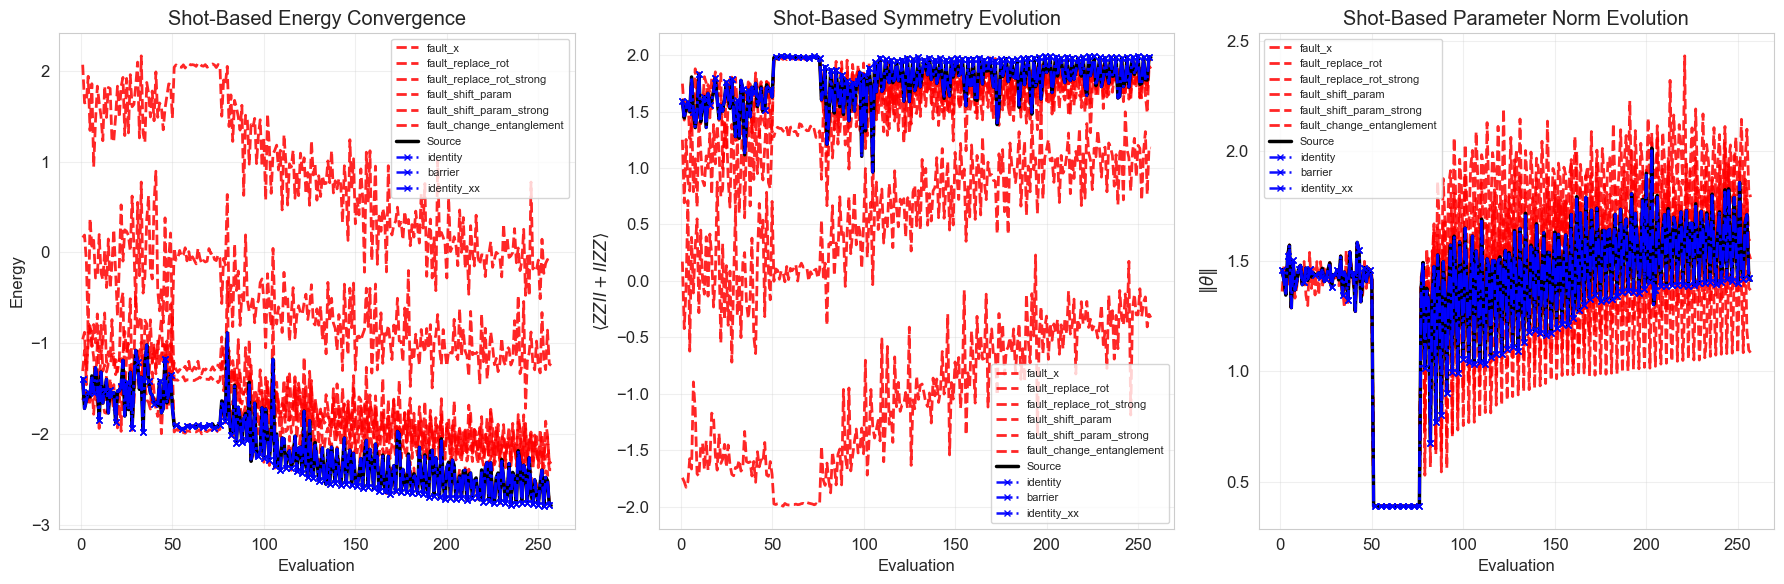

In [4]:
# SHOT-BASED VQE OPTIMIZATION PATHS
# (WITHOUT SAVED TRACE CSV)

# Use one representative initial point for the figure
initial_point = initial_points[0]

source_result, source_trace = run_vqe_trace_shots(
    ansatz=ansatz,
    hamiltonian=H,
    symmetry_op=symmetry_op,
    initial_point=initial_point,
    shots=SHOTS,
    maxiter=MAXITER,
    seed=100_000,  
)

followup_traces = []

for idx, (name, relation_info) in enumerate(relations.items()):
    transform = relation_info["transform"]

    follow_ansatz = apply_transform(
        transform=transform,
        ansatz=ansatz,
        seed=1_000 + idx,
    )

    if follow_ansatz.num_parameters == ansatz.num_parameters:
        follow_initial_point = initial_point
    else:
        follow_initial_point = rng.uniform(
            -0.1,
            0.1,
            follow_ansatz.num_parameters,
        )

    _, follow_trace = run_vqe_trace_shots(
        ansatz=follow_ansatz,
        hamiltonian=H,
        symmetry_op=symmetry_op,
        initial_point=follow_initial_point,
        shots=SHOTS,
        maxiter=MAXITER,
        seed=100_000,   # same representative seed as source
    )

    followup_traces.append((name, follow_trace))

valid_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" not in name
]

fault_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" in name
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ENERGY PLOT

for name, follow_trace in fault_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[0].plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[0].set_xlabel("Evaluation")
axes[0].set_ylabel("Energy")
axes[0].set_title("Shot-Based Energy Convergence")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# SYMMETRY PLOT

for name, follow_trace in fault_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[1].plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[1].set_xlabel("Evaluation")
axes[1].set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
axes[1].set_title("Shot-Based Symmetry Evolution")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# PARAMETER NORM PLOT

for name, follow_trace in fault_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[2].plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[2].set_xlabel("Evaluation")
axes[2].set_ylabel(r"$\|\theta\|$")
axes[2].set_title("Shot-Based Parameter Norm Evolution")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# SAVE FIGURE

plt.tight_layout()

plt.savefig(
    figures_dir / "vqe_shot_optimization_paths.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figures_dir / "vqe_shot_optimization_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,phase,relation,type,trace_role,representative_run,eval,energy,symmetry,param_norm
0,shot_based,identity,valid,source,1,1,-1.387695,1.593750,1.462826
1,shot_based,identity,valid,source,1,2,-1.714355,1.443359,1.414508
2,shot_based,identity,valid,source,1,3,-1.628906,1.528320,1.347189
3,shot_based,identity,valid,source,1,4,-1.539062,1.582031,1.525050
4,shot_based,identity,valid,source,1,5,-1.587891,1.497070,1.573920


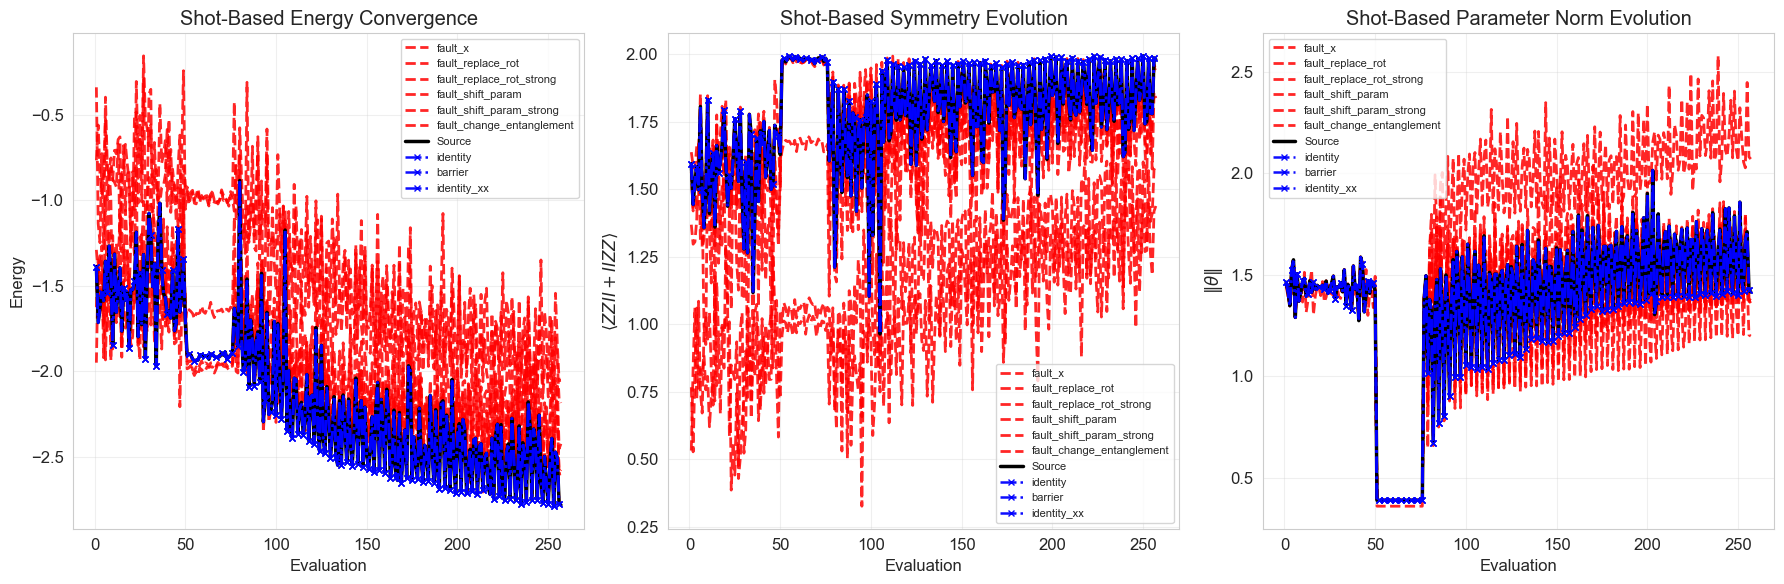

In [9]:
# SHOT-BASED VQE OPTIMIZATION PATHS FROM SAVED TRACE RESULTS

df_vqe_shot_traces = pd.read_csv(
    results_dir / "vqe_trace_results_4q_shot_based.csv"
)

display(df_vqe_shot_traces.head())

# SOURCE TRACE

# Since one representative source trace was saved for each relation,
# we can just take the first one.
source_trace = (
    df_vqe_shot_traces[df_vqe_shot_traces["trace_role"] == "source"]
    .copy()
    .sort_values(["relation", "eval"])
)

first_relation = source_trace["relation"].iloc[0]

source_trace = (
    source_trace[source_trace["relation"] == first_relation]
    .copy()
    .sort_values("eval")
)

# FOLLOW-UP TRACES
followup_traces = []

for relation_name in df_vqe_shot_traces["relation"].unique():
    follow_trace = (
        df_vqe_shot_traces[
            (df_vqe_shot_traces["relation"] == relation_name) &
            (df_vqe_shot_traces["trace_role"] == "followup")
        ]
        .copy()
        .sort_values("eval")
    )

    if len(follow_trace) > 0:
        followup_traces.append((relation_name, follow_trace))

valid_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" not in name
]

fault_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" in name
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ENERGY PLOT

for name, follow_trace in fault_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[0].plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[0].set_xlabel("Evaluation")
axes[0].set_ylabel("Energy")
axes[0].set_title("Shot-Based Energy Convergence")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# SYMMETRY OBSERVABLE PLOT

for name, follow_trace in fault_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[1].plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[1].set_xlabel("Evaluation")
axes[1].set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
axes[1].set_title("Shot-Based Symmetry Evolution")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# PARAMETER NORM PLOT

for name, follow_trace in fault_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[2].plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.5,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=name,
        linestyle="-.",
        linewidth=1.8,
        color="blue",
        marker="x",
        markersize=5,
        markevery=3,
        alpha=0.95,
        zorder=4,
    )

axes[2].set_xlabel("Evaluation")
axes[2].set_ylabel(r"$\|\theta\|$")
axes[2].set_title("Shot-Based Parameter Norm Evolution")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# SAVE FIGURE

plt.tight_layout()

plt.savefig(
    figures_dir / "vqe_shot_optimization_paths.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    figures_dir / "vqe_shot_optimization_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# THRESHOLD SENSITIVITY TEST for the 4 qubit shot based experiment

df = pd.read_csv(results_dir / "vqe_run_level_results_4q_shot_based.csv")

# Keep only the shot-based phase if needed
if "phase" in df.columns:
    df = df[df["phase"] == "shot_based"].copy()

# Candidate thresholds for the active oracle
ENERGY_VALUES = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
SYMMETRY_VALUES = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]

tuning_results = []

for e_th in ENERGY_VALUES:
    for s_th in SYMMETRY_VALUES:

        # Match the actual active oracle in your shot-based experiment
        predicted_violation = (
            (df["delta_E"] > e_th) |
            (df["avg_sym_diff"] > s_th)
        )

        valid_mask = df["type"] == "valid"
        fault_mask = df["type"] == "fault"

        fp_rate = predicted_violation[valid_mask].mean() * 100
        tp_rate = predicted_violation[fault_mask].mean() * 100

        tp = int(predicted_violation[fault_mask].sum())
        fn = int((~predicted_violation[fault_mask]).sum())
        fp = int(predicted_violation[valid_mask].sum())
        tn = int((~predicted_violation[valid_mask]).sum())

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        tuning_results.append({
            "energy_threshold": e_th,
            "symmetry_threshold": s_th,
            "fp_rate_pct": round(fp_rate, 2),
            "tp_rate_pct": round(tp_rate, 2),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })

df_tuning = pd.DataFrame(tuning_results)

# Prefer zero false positives, then strongest fault detection
df_best = df_tuning[df_tuning["fp_rate_pct"] == 0].sort_values(
    by=["f1_score", "tp_rate_pct"],
    ascending=[False, False]
)

display(df_best.head(20))

df_tuning.to_csv(
    results_dir / "vqe_threshold_sensitivity_4q_shot_based.csv",
    index=False
)